# 04 Baseline Modeling & Interpretation

+ Export in the synthetic prelim. modeling done in `src/tft/models/baseline.py`
+ Begin modeling on MIMIC-IV v3.1 data, train on 80/test on 20 and need to produce as many viz. as possible before TFT training
    + Nothing slips through in the shallow learning phase.

    



**Necessary inputs**

+ `data/final_static_df.parquet`
+ `data/timeseries.parquet`
+ `data/train_data.parquet`

**Outputs**

+ `models/baselines/logreg_elasticnet_calibrated.joblib`
+ `models/baselines/baseline_comparison.csv`
+ `models/baselines/logreg_calbration_curve.png`
+ `models/baselines/roc_pr_curves.png`
+ `models/baselines/coef_plot.png`
+ `models/baselines/sofa_distribution.png`



In [6]:
from __future__ import annotations
from pathlib import Path
import sys
from pydoc import classify_class_attrs

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str[ROOT / 'src'])

from icu_tft.models.baselines import(
    TARGET,
    SOFA_COLUMNS,
    STATIC_FEATURES,
    TIMESERIES_MEAN_FEATURES,
    compare_baselines,
    compute_sofa_score,
    load_logreg_pipeline,
)

DATA_DIR = ROOT / 'data'
MODELS_DIR = ROOT / 'src' / 'icu_tft' / 'models' / 'baselines'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi':130, 'font.size':11})

print('ROOT: ', ROOT)
print('DATA DIR: ', DATA_DIR)
print('MODELS DIR: ', MODELS_DIR)

ROOT:  /Users/longer/ICU_Mortality_Prediction
DATA DIR:  /Users/longer/ICU_Mortality_Prediction/data
MODELS DIR:  /Users/longer/ICU_Mortality_Prediction/src/icu_tft/models/baselines


In [7]:
df = pd.read_parquet(DATA_DIR / 'processed' / 'train_data.parquet')

df.head()


,stay_id,age,age_binned,gender_M,race_Asian,race_Black,race_Hispanic,race_Other,race_White,admission_type_Elective,...,bun_missing_mean24h,sodium_missing_mean24h,potassium_missing_mean24h,bicarbonate_missing_mean24h,lactate_missing_mean24h,wbc_missing_mean24h,hemoglobin_missing_mean24h,platelets_missing_mean24h,inr_missing_mean24h,sofa_24h
0,37081114,86.0,3,0,0,0,0,0,1,0,...,0.708333,1.0,1.0,1.000000,1.000000,1.000000,0.708333,1.000000,1.000000,1
1,37067082,55.0,1,0,0,0,0,0,1,0,...,1.000000,1.0,1.0,1.000000,1.000000,0.708333,0.708333,1.000000,0.708333,0
2,31205490,46.0,1,0,0,0,0,0,1,0,...,1.000000,1.0,1.0,1.000000,1.000000,0.416667,1.000000,1.000000,1.000000,0
3,37510196,68.0,2,0,0,1,0,0,0,0,...,0.666667,1.0,1.0,0.666667,1.000000,0.666667,0.958333,0.958333,0.666667,4
4,39060235,53.0,1,0,0,0,0,1,0,0,...,1.000000,1.0,1.0,1.000000,0.583333,0.375000,0.375000,1.000000,0.708333,1


In [21]:
nulls = df.isna().sum()
nulls.to_csv('train_data_missingness.csv', index=False)

In [24]:
# rows 56-73 contain NaNs
for i in range(55, 73, 1):
    print(df.columns[i])


sbp_mean24h
dbp_mean24h
mbp_mean24h
spo2_mean24h
resp_rate_mean24h
temperature_c_mean24h
gcs_total_mean24h
creatinine_mean24h
bun_mean24h
sodium_mean24h
potassium_mean24h
bicarbonate_mean24h
lactate_mean24h
wbc_mean24h
hemoglobin_mean24h
platelets_mean24h
inr_mean24h
heart_rate_missing_mean24h


In [25]:

df = df.fillna(0)

## ML Techniques

+ Ensembles will most likely be the most effective for this application
+ RFs after naive prelim approach
    + L1 could be useful to drown out the useless covariates as there are 91 over 65,000 records
+ Start out with L1 w/ a passive coef.
+ Should hopefully get the best results with gradient boosting by the end.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, RocCurveDisplay)

X = df.drop(columns='mortality_24h')
y = df['mortality_24h']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=617)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(penalty='l1', solver='saga', C=0.5, random_state=617)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]


/Users/longer/Library/Caches/pypoetry/virtualenvs/icu-tft-MHBul8iT-py3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


accuracy score: 0.9894384529564894
classification report: 

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     13295
           1       0.65      0.11      0.19       150

    accuracy                           0.99     13445
   macro avg       0.82      0.56      0.59     13445
weighted avg       0.99      0.99      0.99     13445

confusion matrix: 

[[13286     9]
 [  133    17]]


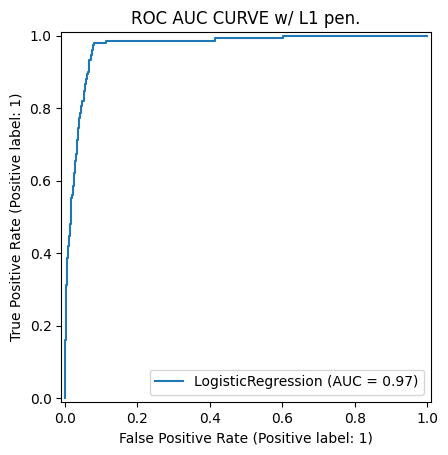

In [27]:
acc = accuracy_score(y_test, y_pred)
print(f'accuracy score: {acc}')

print('classification report: \n')
print(classification_report(y_test, y_pred))

print('confusion matrix: \n')
print(confusion_matrix(y_test, y_pred))

RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title('ROC AUC CURVE w/ L1 pen.')
plt.show()